In [2]:
import pandas as pd
import numpy as np

In [14]:
df = pd.read_csv("data/placement.csv")
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [15]:
df = df.iloc[:,1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [16]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [17]:
import matplotlib.pyplot as plt

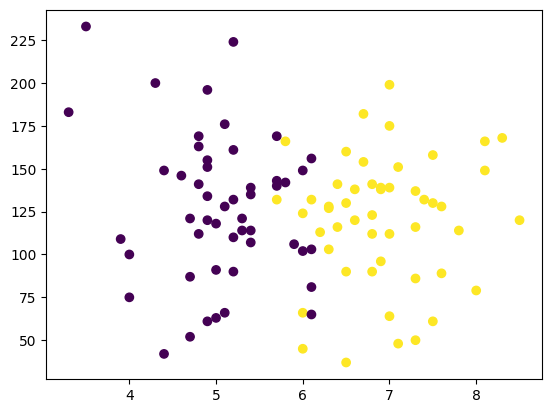

In [19]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

In [26]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [28]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [29]:
y.shape

(100,)

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

In [33]:
X, X_train

(    cgpa     iq
 0    6.8  123.0
 1    5.9  106.0
 2    5.3  121.0
 3    7.4  132.0
 4    5.8  142.0
 ..   ...    ...
 95   4.3  200.0
 96   4.4   42.0
 97   6.7  182.0
 98   6.3  103.0
 99   6.2  113.0
 
 [100 rows x 2 columns],
     cgpa     iq
 58   8.0   79.0
 93   6.8  112.0
 63   6.3  128.0
 51   4.8  141.0
 89   4.9  151.0
 ..   ...    ...
 75   4.8  169.0
 26   7.0  199.0
 21   7.1  151.0
 33   6.0  149.0
 57   6.5  130.0
 
 [90 rows x 2 columns])

In [44]:
X, X_test

(    cgpa     iq
 0    6.8  123.0
 1    5.9  106.0
 2    5.3  121.0
 3    7.4  132.0
 4    5.8  142.0
 ..   ...    ...
 95   4.3  200.0
 96   4.4   42.0
 97   6.7  182.0
 98   6.3  103.0
 99   6.2  113.0
 
 [100 rows x 2 columns],
     cgpa     iq
 26   7.0  199.0
 51   4.8  141.0
 15   5.1  176.0
 10   6.0   45.0
 76   4.9  155.0
 39   4.6  146.0
 28   5.2   90.0
 21   7.1  151.0
 36   5.7  140.0
 67   5.0  118.0)

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [46]:
X_train = scaler.fit_transform(X_train)
X_train[0]

array([-0.29543811,  0.24947105])

In [47]:
X_test = scaler.transform(X_test)
X_test

array([[ 0.83049865,  1.9531069 ],
       [-1.07493279,  0.47831766],
       [-0.81510123,  1.36827668],
       [-0.03560655, -1.9627128 ],
       [-0.98832227,  0.83430127],
       [-1.24815383,  0.60545466],
       [-0.72849071, -0.81847977],
       [ 0.91710917,  0.73259167],
       [-0.29543811,  0.45289026],
       [-0.90171175, -0.10651256]])

In [48]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [49]:
#Model training
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [54]:
y_pred = clf.predict(X_test)

In [52]:
y_test

26    1
51    0
15    0
10    1
76    0
39    0
28    0
21    1
36    0
67    0
Name: placement, dtype: int64

In [50]:
from sklearn.metrics import accuracy_score

In [56]:
accuracy_score(y_test, y_pred)

0.9

In [57]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

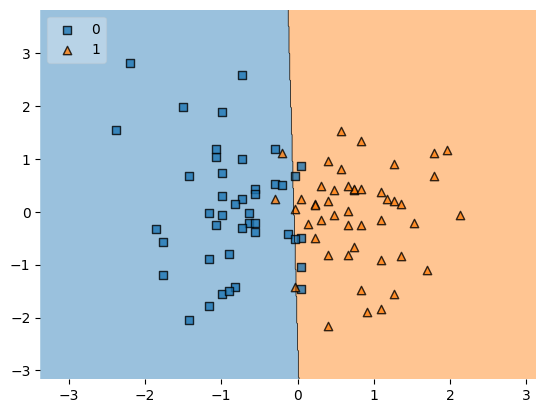

In [58]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [61]:
import pickle
pickle.dump(clf, open("placement_model.pkl", "wb"))

In [63]:
filename = "placement_model.pkl"
with open(filename, "rb") as file:
    loaded_model = pickle.load(file)

In [64]:
predictions = loaded_model.predict(X_test)
print(predictions)

[1 0 0 0 0 0 0 1 0 0]
